In [2]:
# Стилизация отчета в стиле Notion
from IPython.display import HTML, display

style = """
<style>
    /* Центрирование основного контейнера ноутбука */
    #notebook-container, .container, .jp-Notebook {
        max-width: 1000px !important;
        margin: 0 auto !important;
        background-color: E8E8E8 !important;
        box-shadow: none !important;
    }
    
   /* Выравнивание вывода (output) по левому краю внутри контейнера */
    .output_subarea, .jp-OutputArea-output {
        text-align: left !important;
        padding: 0 !important;
    }

    /* 1. Центрируем контейнер с результатами выполнения */
    .jp-OutputArea-child, .output_area {
        max-width: 1000px; /* Ширина "Notion-блока" */
        margin: 0 auto !important;
        text-align: left; 
    }

    /* Выравнивание markdown по ширине */
    .jp-MarkdownOutput p,
    .jp-MarkdownOutput li,
    .text_cell_render p,
    .text_cell_render li {
        text-align: justify !important;
        text-justify: inter-word !important;
    }

    .jp-MarkdownOutput h1,
    .jp-MarkdownOutput h2,
    .jp-MarkdownOutput h3,
    .jp-MarkdownOutput h4,
    .text_cell_render h1,
    .text_cell_render h2,
    .text_cell_render h3,
    .text_cell_render h4 {
        text-align: left !important;
    }
        
    /* 2. Делаем таблицы Pandas аккуратными (в стиле Notion) */
    table.dataframe {
        border: none !important;
        margin: 0 auto !important;
        font-family: sans-serif !important;
        border-collapse: collapse !important;
    }

    table.dataframe th { 
        padding: 8px !important;
        border-bottom: 2px solid #8C8C8C !important;
        text-align: left !important;
    }
    
    table.dataframe td {     
        border-bottom: 1px solid #8C8C8C !important;
    }

    /* 3. Центрируем графики (matplotlib, plotly) */
    .output_png img,
    .jp-OutputArea-output img {
        width: 100% !important;
        height: auto !important;
    }
</style>
"""
display(HTML(style))

<h1><strong> RFM СЕГМЕНТАЦИЯ </strong></h1>

<b><i>RFM-сегментация</i></b> — метод анализа и классификации клиентской базы на основе их покупательского поведения для повышения лояльности и выручки. Она делит клиентов на группы, анализируя три фактора: <u>давность (Recency), частоту (Frequency) и сумму покупок (Monetary)</u>. Этот инструмент позволяет выявить наиболее прибыльных покупателей, клиентов «в зоне риска» и разработать для них персонализированные предложения.

In [3]:
# Импорт нужных библиотек
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import os
import clickhouse_connect
import statistics as stats

# Стиль для графиков
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
## Подключение к базе данных ClickHouse и загрузка данных в DataFrame
# Данные для подключения к ClickHouse
ch_host = 'localhost'
ch_port = '8123'
ch_user = os.getenv('CLICKHOUSE_USER')
ch_password = os.getenv('CLICKHOUSE_PASSWORD')
ch_database = 'dwh'

# Создание соединение с ClickHouse
ch_connect = clickhouse_connect.get_client(
    host=ch_host,
    port=ch_port,
    username=ch_user,
    password=ch_password,
    database=ch_database
)

<h3><strong> 1. ПОДГОТОВКА ДАННЫХ </strong></h3>

In [5]:
# Загрузка и чтение данных с clickhouse
df = ch_connect.query_df('SELECT * FROM dwh.sales_fact')
print("\033[1m" + 'ТАБЛИЦА ПО ПРОДАЖАМ ЗАГРУЖЕНА УСПЕШНО!' + "\033[1m" + '\n')

ТАБЛИЦА ПО ПРОДАЖАМ ЗАГРУЖЕНА УСПЕШНО!



In [6]:
# Оставляем только нужные столбцы
rfm_df = df[['order_id', 'order_date', 'customer_name', 'sales']]
print('Для выполнения RFM сегментации нам не нужна вся таблица по продажам, оставляем только нужные: ' + "\033[1m" + 'order_id, order_date, customer_name, sales.' + "\033[1m" + '\n')
display(rfm_df.head(5))

Для выполнения RFM сегментации нам не нужна вся таблица по продажам, оставляем только нужные: order_id, order_date, customer_name, sales.



,order_id,order_date,customer_name,sales
0,CA-2018-103800,2018-01-03,Darren Powers,16
1,CA-2018-112326,2018-01-04,Phillina Ober,12
2,CA-2018-112326,2018-01-04,Phillina Ober,273
3,CA-2018-112326,2018-01-04,Phillina Ober,4
4,CA-2018-141817,2018-01-05,Mick Brown,20


<h3><strong> 2. RFM МЕТРИКИ </strong></h3>

a) Первая метрика - давность покупки клиентов (дней назад) <b>(recency)</b>.<br>
Для вычисления этой метрики (столбец <i>'recency'</i>) необходимо определить дату последней покупки для каждого клиента (last_order_date) и отнять ее от даты самой последней покупки в магазине (max_date).<br>
<b>Ранжирование покупателей:</b><br>
- recency = 0 дней -> R_score = 3 (покупал в последний день, отличный клиент)<br>
- recency = 1165 дней -> R_score = 1 (покупал очень давно, плохой клиент)

In [7]:
# Вычисление метрики давности - Recency
recency_df = rfm_df.groupby('customer_name').order_date.max().reset_index()
recency_df.columns = ['customer_name', 'last_order_date']
recency_df['max_date'] = rfm_df.order_date.max()
recency_df['recency'] = (recency_df.max_date - recency_df.last_order_date).dt.days
recency_df = recency_df.sort_values(by='recency', ascending=True)

# Разбитие на развные квантили для ранжирования
recency_df['R_score'] = pd.qcut(recency_df.recency, q=3, labels=[3, 2, 1])
recency_df.reset_index(drop=True)
display(recency_df)

,customer_name,last_order_date,max_date,recency,R_score
589,Patrick O'Donnell,2021-12-30,2021-12-30,0,3
160,Chuck Clark,2021-12-30,2021-12-30,0,3
263,Erica Bern,2021-12-30,2021-12-30,0,3
370,Jill Matthias,2021-12-30,2021-12-30,0,3
116,Bruce Stewart,2021-12-29,2021-12-30,1,3
...,...,...,...,...,...
777,Valerie Takahito,2019-04-05,2021-12-30,1000,1
179,Craig Molinari,2019-03-01,2021-12-30,1035,1
625,Ricardo Emerson,2018-12-29,2021-12-30,1097,1
302,Georgia Rosenberg,2018-11-21,2021-12-30,1135,1


б) Вторая метрика - частота покупок <b>(frequency)</b>.<br>
Расчет частоты покупки производится на основании подсчета количества заказов каждого покупателя.<br>
<b>Ранжирование покупателей:</b><br>
- frequency = 1 -> F_score = 1 (покупал очень редко, только один раз, плохой клиент)<br>
- frequency = 17 -> F_score = 3 (покупал часто, отличный клиент)

In [8]:
# Вычисление метрики частоты - frequency 
frequency_df = rfm_df.groupby('customer_name').order_id.nunique().reset_index().sort_values(by='order_id', ascending=False)
frequency_df.columns = ['customer_name', 'frequency']
frequency_df['F_score'] = pd.qcut(frequency_df.frequency, q=3, labels=[1, 2, 3])
frequency_df = frequency_df.reset_index(drop=True)
display(frequency_df)

,customer_name,frequency,F_score
0,Emily Phan,17,3
1,Sally Hughsby,13,3
2,Noel Staavos,13,3
3,Patrick Gardner,13,3
4,Zuschuss Carroll,13,3
...,...,...,...
788,Roland Murray,1,1
789,Jenna Caffey,1,1
790,Anemone Ratner,1,1
791,Susan MacKendrick,1,1


в) Третяя метрика - сумма покупок (Monetary)<br>
Расчет суммы покупок производится суммированием всех покупок каждого покупателя.<br>
<b>Ранжирование покупателей:</b><br>
- monetary = 1 -> M_score = 1 (покупал на малую сумму, плохой клиент)<br>
- monetary = 25042 -> M_score = 3 (покупал на большую сумму, отличный клиент)

In [9]:
# Вычисление метрики - суммы покупок (monetary)
monetary_df = rfm_df.groupby('customer_name').sales.sum().reset_index().sort_values(by='sales', ascending=False)
monetary_df.columns = ['customer_name', 'monetary']
monetary_df['M_score'] = pd.qcut(monetary_df.monetary, q=3, labels=[1, 2, 3])
monetary_df = monetary_df.reset_index(drop=True)
display(monetary_df)

,customer_name,monetary,M_score
0,Sean Miller,25042,3
1,Tamara Chand,19050,3
2,Raymond Buch,15117,3
3,Tom Ashbrook,14596,3
4,Adrian Barton,14476,3
...,...,...,...
788,Roy Skaria,22,1
789,Carl Jackson,17,1
790,Mitch Gastineau,16,1
791,Thais Sissman,5,1


<h3><strong> 2. ОБЪЕДИНЕНИЕ ТРЕХ МЕТРИК И РАЗДЕЛЕНИЕ НА СЕГМЕНТЫ </strong></h3>
После ранжирования покупателей по трем метрикам, нужно создать RFM коды. Они создаются путем соединения значений трех метрик (111, 222, 333).


In [10]:
# Объединение всех метрик и разделение покупателей на сегменты
rfm = recency_df.merge(frequency_df, on='customer_name').merge(monetary_df, on='customer_name')
#rfm = rfm[['customer_name', 'R_score', 'F_score', 'M_score']]
rfm['RFM_code'] = rfm.R_score.astype(str) + rfm.F_score.astype(str) + rfm.M_score.astype(str)
rfm = rfm.sort_values(by='customer_name', ascending=False).reset_index(drop=True)

In [11]:
# Функция для маппинга по сегментам
def segment_rfm(score):
    if score in ['333', '332']: return '1. Чемпионы'
    elif score in ['331', '233', '232', '231']: return '2. Лояльные'
    elif score in ['313', '312', '311']: return '3. Новые клиенты'
    elif score in ['323', '322', '321']: return '4. Перспективные'
    elif score in ['223', '222', '221', '213', '212', '211']: return '5. В зоне риска'
    elif score in ['133', '132', '131', '123', '122', '121']: return '6. Уходящие ценные'
    elif score in ['113', '112']: return '7. Спящие разовые'
    elif score == '111': return '8. Потерянные'
    else: return 'Другое'

# Создание колонки Сегменты 
rfm['segment'] = rfm['RFM_code'].astype(str).apply(segment_rfm)
print('Первые строки таблицы с RFM кодами')
display(rfm.head(10))

Первые строки таблицы с RFM кодами


,customer_name,last_order_date,max_date,recency,R_score,frequency,F_score,monetary,M_score,RFM_code,segment
0,Zuschuss Donatelli,2021-06-11,2021-12-30,202,1,5,1,1494,2,112,7. Спящие разовые
1,Zuschuss Carroll,2021-11-06,2021-12-30,54,2,13,3,8028,3,233,2. Лояльные
2,Yoseph Carroll,2021-12-26,2021-12-30,4,3,5,1,5455,3,313,3. Новые клиенты
3,Yana Sorensen,2021-12-21,2021-12-30,9,3,8,3,6722,3,333,1. Чемпионы
4,Xylona Preis,2021-11-17,2021-12-30,43,2,11,3,2375,2,232,2. Лояльные
5,William Brown,2021-12-10,2021-12-30,20,3,11,3,6159,3,333,1. Чемпионы
6,Vivian Mathis,2021-09-04,2021-12-30,117,2,5,1,381,1,211,5. В зоне риска
7,Vivek Sundaresam,2021-05-23,2021-12-30,221,1,4,1,1057,1,111,8. Потерянные
8,Vivek Grady,2021-03-19,2021-12-30,286,1,5,1,427,1,111,8. Потерянные
9,Vivek Gonzalez,2021-07-29,2021-12-30,154,1,6,2,846,1,121,6. Уходящие ценные


##### Сегментация пользователей на основе RFM-анализа

| № | Сегмент | RFM-коды | Описание | Стратегия взаимодействия |
|:---|:---|:---|:---|:---|
| 1 | **Чемпионы (VIP)** | `333`, `332` | **Идеал.** Купили недавно, покупают постоянно, тратят много. | Не давать скидки. Давать эксклюзив: ранний доступ к новинкам, премиум-сервис. |
| 2 | **Лояльное ядро** | `331`, `233`, `232`, `231` | **База.** Покупают часто и стабильно. | Поддерживать контакт. Предлагать сопутствующие товары (Cross-sell) для роста чека. |
| 3 | **Новые клиенты** | `313`, `312`, `311` | **Только пришли.** Свежая покупка, пока единственная. | Цель: заставить купить во 2-й раз. Welcome-бонусы и цепочка писем. |
| 4 | **Перспективные** | `323`, `322`, `321` | **Растущие.** Вернулись за 2-й покупкой недавно. Почти лояльные. | Закрепить привычку. Бонусы за рекомендацию или накопительная карта. |
| 5 | **В зоне риска** | `223-221`, `213-211` | **Остывают.** Покупали 1-2 раза, начали забывать о нас. | Нужен триггер. Персональная подборка, скидка с ограниченным сроком действия. |
| 6 | **Уходящие ценные** | `133-131`, `123-121` | **Нельзя потерять.** Раньше были активны, но давно исчезли. | Звонок менеджера, опрос "Что не так?", агрессивные скидки для возвращения. |
| 7 | **Спящие разовые** | `113`, `112` | **Залетные.** Зашли давно, купили один раз, но чек был средний/высокий. | Массовая реактивация. Если не реагируют — отпускаем в архив. |
| 8 | **Потерянные (Отток)**| `111` | **Балласт.** Купили очень давно, один раз и на копейки. | Игнорировать. Не тратить на них рекламный бюджет. |

In [49]:
# Таблица со средними показателями по сегментам
mean_table = rfm.groupby('segment').agg(
    mean_recency=('recency', 'mean'),
    mean_frequency=('frequency', 'mean'),
    mean_monetary=('monetary', 'mean')
).round(1).sort_values('mean_monetary', ascending=False)
mean_table.reset_index(inplace=True)
mean_table = mean_table.rename(columns={
    'segment': 'RFM сегмент',
    'mean_recency': 'Средняя давность покупок', 
    'mean_frequency': 'Средняя частота покупок',
      'mean_monetary': 'Средняя сумма покупок'
      })
print('\nСредние показатели по сегментам:')
display(mean_table)
print('\n\nПостроим графики для наглядного сравнения сегментов по количеству покупателей, выручке и среднему чеку.')


Средние показатели по сегментам:


,RFM сегмент,Средняя давность покупок,Средняя частота покупок,Средняя сумма покупок
0,1. Чемпионы,21.7,9.6,4297.7
1,2. Лояльные,69.2,9.2,3743.4
2,6. Уходящие ценные,248.2,7.7,3570.3
3,7. Спящие разовые,401.0,4.4,3397.4
4,4. Перспективные,21.9,6.6,3083.8
5,5. В зоне риска,79.3,5.2,2744.7
6,3. Новые клиенты,19.7,4.2,1645.3
7,8. Потерянные,415.9,3.3,719.7




Построим графики для наглядного сравнения сегментов по количеству покупателей, выручке и среднему чеку.


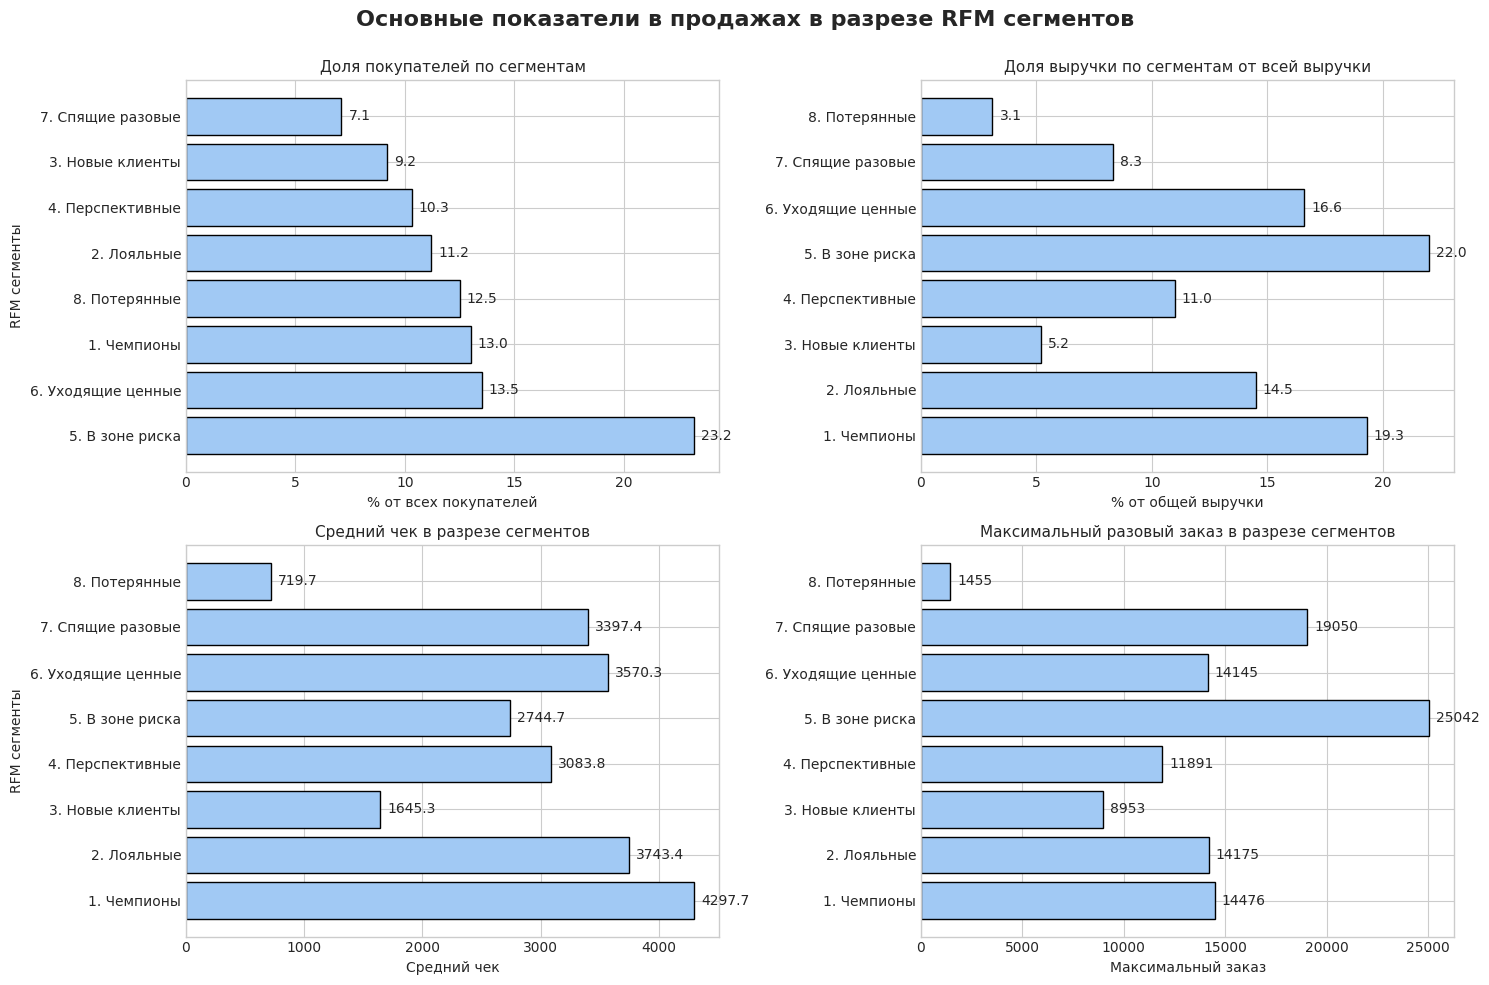

In [25]:
# Визуализация показателей в продажах в разрезе сегментов
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Основные показатели в продажах в разрезе RFM сегментов', fontsize=16, fontweight='bold')

gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Количество покупателей в сегментах
counts = (rfm.segment.value_counts() / len(rfm) * 100).round(1)
ax1.set_title('Доля покупателей по сегментам', fontsize=11)
bars = ax1.barh(counts.index, counts.values, color='#a1c9f4', edgecolor='black')
ax1.bar_label(bars, labels=counts.values, padding=5, fontsize=10)
ax1.set_xlabel('% от всех покупателей')
ax1.set_ylabel('RFM сегменты')

# Выручка в каждом сегменте
sales = (rfm.groupby('segment').monetary.sum() / rfm.groupby('segment').monetary.sum().sum() * 100).round(1)
ax2.set_title('Доля выручки по сегментам от всей выручки', fontsize=11)
barh_sales = ax2.barh(sales.index, sales.values, color='#a1c9f4', edgecolor='black')
ax2.bar_label(barh_sales, labels=sales.values, padding=5, fontsize=10)
ax2.set_xlabel('% от общей выручки')

# Средний чек в сегментах
aov = rfm.groupby('segment').monetary.agg('mean').round(1)
ax3.set_title('Средний чек в разрезе сегментов', fontsize=11)
bar_aov = ax3.barh(aov.index, aov.values, color='#a1c9f4', edgecolor='black')
ax3.bar_label(bar_aov, labels=aov.values, padding=5, fontsize=10)
ax3.set_xlabel('Средний чек')
ax3.set_ylabel('RFM сегменты')

# Максимальный разовый заказ в сегментах
max_order = rfm.groupby('segment').monetary.agg('max')
ax4.set_title('Максимальный разовый заказ в разрезе сегментов', fontsize=11)
bar_max = ax4.barh(max_order.index, max_order.values, color='#a1c9f4', edgecolor='black')
ax4.bar_label(bar_max, labels=max_order.values, padding=5, fontsize=10)
ax4.set_xlabel('Максимальный заказ')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**Аналитический вывод:**

Клиентская база магазина имеет тревожный сигнал: наибольшая доля покупателей (23.2%) сосредоточена в сегменте "В зоне риска" — они уже начали уходить. Вместе с "Уходящими ценными" (13.5%) это означает, что **36.7% клиентов с совокупной выручкой ~39% находятся под угрозой потери**. При этом "Чемпионы" и "Лояльные" вместе составляют лишь 24% базы, но генерируют 33.8% выручки с самыми высокими чеками. Приоритет: вернуть "Уходящих ценных" (высокий чек, помнят бренд) и конвертировать "В зоне риска" во второй заказ, пока не поздно.